# Machine Learning: Prediction of ER Status

## Objective

The objective of this analysis is to evaluate whether gene expression profiles can be used to predict estrogen receptor (ER) status in breast cancer samples.

Following the exploratory and differential expression analysis performed in `01_data_exploration`, this notebook applies supervised machine learning to classify ER-positive and ER-negative samples.

## Analysis workflow

1. Match clinical and gene expression data.
2. Resolve duplicated gene probes by averaging (consistent with `01_data_exploration`).
3. Encode ER status as a binary variable.
4. Split the data into stratified training and test sets.
5. Perform feature selection exclusively on the training set.
6. Impute missing values using parameters learned from the training set.
7. Standardize the data for Logistic Regression.
8. Train and evaluate Logistic Regression.
9. Train and evaluate Random Forest.
10. Compare model performance using multiple classification metrics.
11. Interpret the genes contributing most strongly to the final model.

## Dataset

After matching the clinical and expression datasets, 519 samples were retained:

- 401 ER-positive
- 118 ER-negative
- 17,268 gene probes, mapping to 17,264 unique gene symbols after resolving duplicated probes (same criterion as `01_data_exploration`: probes sharing a Hugo_Symbol are averaged)

The data are divided into training and test sets using stratification to preserve the ER-status distribution.

## Preventing data leakage

All data-dependent preprocessing steps used for model development are performed using the training set only.

Feature selection, missing-value imputation and scaling are therefore learned from the training data and subsequently applied to the test data.

The test set is kept independent until final model evaluation.


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
clinical = pd.read_csv(
    "../data/raw/data_clinical_sample.txt",
    sep="\t",
    comment="#"
)

expression = pd.read_csv(
    "../data/raw/data_mrna_agilent_microarray.txt",
    sep="\t"
)

clinical.shape, expression.shape

((825, 28), (17268, 528))

In [3]:
clinical_er = clinical[
    clinical["ER_STATUS"].isin(["Positive", "Negative"])
][
    ["SAMPLE_ID", "PATIENT_ID", "ER_STATUS"]
].copy()

print("Clinical samples with valid ER status:", len(clinical_er))
print()
print(clinical_er["ER_STATUS"].value_counts())

Clinical samples with valid ER status: 780

ER_STATUS
Positive    601
Negative    179
Name: count, dtype: int64


In [4]:
clinical_samples = set(clinical_er["SAMPLE_ID"])
expression_samples = set(expression.columns[1:])

common_samples = sorted(
    clinical_samples & expression_samples
)

print(f"Common samples: {len(common_samples)}")

Common samples: 519


In [5]:
expression_common = expression[
    ["Hugo_Symbol"] + common_samples
].copy()

print("Expression matrix:", expression_common.shape)

Expression matrix: (17268, 520)


In [6]:
X = expression_common.set_index("Hugo_Symbol").T

print("X shape:", X.shape)

X shape: (519, 17268)


## Resolving duplicated gene probes

As in `01_data_exploration`, the gene expression data contains duplicated Hugo_Symbol identifiers: some genes are measured by more than one microarray probe (e.g. targeting different exons or transcript isoforms).

To keep the two notebooks consistent, duplicated probes are resolved here in the same way as in the exploratory notebook: by averaging the expression values of probes sharing the same gene symbol. This is done before the train/test split, since it only consolidates gene columns and does not use any label information, so it cannot introduce data leakage.


In [7]:
print("Gene columns before resolving duplicates:", X.shape[1])

X = X.T.groupby(level=0).mean().T

print("Gene columns after resolving duplicates:", X.shape[1])


Gene columns before resolving duplicates: 17268
Gene columns after resolving duplicates: 17264


In [8]:
clinical_by_sample = clinical_er.set_index("SAMPLE_ID")

y = clinical_by_sample.loc[X.index, "ER_STATUS"]

print("y shape:", y.shape)
print()
print(y.value_counts())

y shape: (519,)

ER_STATUS
Positive    401
Negative    118
Name: count, dtype: int64


In [9]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Same samples:", X.index.equals(y.index))
print("Duplicated samples:", X.index.duplicated().sum())
print("Missing ER labels:", y.isna().sum())

X shape: (519, 17264)
y shape: (519,)
Same samples: True
Duplicated samples: 0
Missing ER labels: 0


In [10]:
y_binary = y.map({
    "Negative": 0,
    "Positive": 1
})

print(y_binary.value_counts())

ER_STATUS
1    401
0    118
Name: count, dtype: int64


## Train-Test Split

The dataset is divided into training and test sets before feature selection and model preprocessing.

A stratified split is used so that both subsets retain a similar proportion of ER-positive and ER-negative samples.

The test set is kept completely independent and is only used for final evaluation.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    stratify=y_binary,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (415, 17264)
X_test: (104, 17264)
y_train: (415,)
y_test: (104,)


In [12]:
print("Training set:")
print(y_train.value_counts())

print("\nTest set:")
print(y_test.value_counts())

Training set:
ER_STATUS
1    321
0     94
Name: count, dtype: int64

Test set:
ER_STATUS
1    80
0    24
Name: count, dtype: int64


In [13]:
train_positive = X_train[y_train == 1]
train_negative = X_train[y_train == 0]

print("Positive:", train_positive.shape)
print("Negative:", train_negative.shape)

Positive: (321, 17264)
Negative: (94, 17264)


## Feature Selection Using the Training Set

Feature selection is performed exclusively on the training data.

Genes are compared between ER-positive and ER-negative training samples using the Mann-Whitney U test. P-values are corrected using the Benjamini-Hochberg procedure.

Because expression values are on a log2 scale, a mean difference of 1 corresponds approximately to a 2-fold change in relative expression. Selecting genes on FDR < 0.05 alone would retain the large majority of genes tested, so genes are retained only when they satisfy both statistical significance (FDR < 0.05) and this effect-size criterion (absolute mean difference >= 1).

This produces a reduced set of candidate genes for machine-learning models while preventing information from the test set from influencing feature selection.


In [14]:
print("Total missing values in X_train:", X_train.isna().sum().sum())

genes_with_missing = X_train.isna().any(axis=0).sum()

print("Genes with missing values:", genes_with_missing)

Total missing values in X_train: 1209
Genes with missing values: 430


In [15]:
print("Missing values in ER-positive samples:",
      train_positive.isna().sum().sum())

print("Missing values in ER-negative samples:",
      train_negative.isna().sum().sum())

Missing values in ER-positive samples: 985
Missing values in ER-negative samples: 224


In [16]:
from scipy.stats import mannwhitneyu

results_train = []

for gene in X_train.columns:
    
    positive = train_positive[gene].dropna()
    negative = train_negative[gene].dropna()
    
    statistic, p_value = mannwhitneyu(
        positive,
        negative,
        alternative="two-sided"
    )
    
    mean_difference = positive.mean() - negative.mean()
    
    results_train.append({
        "Gene": gene,
        "p_value": p_value,
        "mean_difference": mean_difference
    })

results_train = pd.DataFrame(results_train)

print("Results shape:", results_train.shape)

Results shape: (17264, 3)


In [17]:
print("Number of results:", len(results_train))
print("All p-values are numeric:",
      pd.api.types.is_numeric_dtype(results_train["p_value"]))
print("Missing p-values:", results_train["p_value"].isna().sum())

Number of results: 17264
All p-values are numeric: True
Missing p-values: 0


In [18]:
from statsmodels.stats.multitest import multipletests

results_train["FDR"] = multipletests(
    results_train["p_value"],
    method="fdr_bh"
)[1]

In [19]:
# Inspect the most statistically significant genes in the training set

results_train.sort_values("FDR").head(20)

,Gene,p_value,mean_difference,FDR
5091,ESR1,9.034288e-42,5.255793,1.559680e-37
372,AGR3,5.381062e-40,6.652842,4.644933e-36
5966,GATA3,8.760962e-40,3.039548,5.041641e-36
2523,CA12,1.106253e-37,3.520366,3.305845e-34
14784,TBC1D9,1.148927e-37,3.290835,3.305845e-34
2351,C6orf211,1.085492e-37,2.104846,3.305845e-34
13842,SLC39A6,1.594502e-37,2.639961,3.440936e-34
15020,THSD4,1.554832e-37,2.576255,3.440936e-34
2373,C6orf97,2.369649e-37,2.989859,4.545514e-34
9198,MLPH,9.862545e-37,2.920981,1.702670e-33


In [20]:
(results_train["FDR"] < 0.05).sum()

np.int64(10830)

In [21]:
selected_genes = results_train[
    (results_train["FDR"] < 0.05) &
    (results_train["mean_difference"].abs() >= 1.0)
]["Gene"].tolist()

print("Selected genes:", len(selected_genes))

Selected genes: 1009


In [22]:
X_train_selected = X_train[selected_genes].copy()
X_test_selected = X_test[selected_genes].copy()

print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

X_train_selected shape: (415, 1009)
X_test_selected shape: (104, 1009)


In [23]:
print("Missing values in X_train_selected:",
      X_train_selected.isna().sum().sum())

print("Missing values in X_test_selected:",
      X_test_selected.isna().sum().sum())

Missing values in X_train_selected: 26
Missing values in X_test_selected: 2


## Data Preprocessing

The selected training and test features are prepared for model training.

Missing expression values are imputed using the median of each gene calculated from the training set. The same learned medians are then applied to the test set.

For Logistic Regression, gene expression is subsequently standardized using parameters learned from the training set.

This ensures that the test data do not influence any preprocessing step.

In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train_selected)
X_test_imputed = imputer.transform(X_test_selected)

print("X_train_imputed shape:", X_train_imputed.shape)
print("X_test_imputed shape:", X_test_imputed.shape)

X_train_imputed shape: (415, 1009)
X_test_imputed shape: (104, 1009)


In [25]:
print("Missing values in X_train:",
      np.isnan(X_train_imputed).sum())

print("Missing values in X_test:",
      np.isnan(X_test_imputed).sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (415, 1009)
X_test_scaled shape: (104, 1009)


## Logistic Regression

Logistic Regression is used as an interpretable linear classification model.

The model estimates the probability that a sample belongs to the ER-positive class based on the selected gene expression features.

Model performance is evaluated on the independent test set using accuracy, precision, recall, F1-score and ROC-AUC.

In [27]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions:", y_pred[:10])
print("Probabilities:", y_prob[:10])

Predictions: [1 1 0 1 1 1 1 1 1 1]
Probabilities: [0.99280454 0.99917434 0.33457229 0.98370075 0.99996232 0.99988745
 0.99968114 0.99999748 0.99798496 0.99994163]


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

Accuracy:  0.923
Precision: 0.962
Recall:    0.938
F1-score:  0.949
ROC-AUC:   0.900


In [30]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[21,  3],
       [ 5, 75]])

## Random Forest

Random Forest is used as a complementary non-linear classification model.

Unlike Logistic Regression, Random Forest can capture non-linear relationships and interactions between genes.

The model is evaluated using the same independent test set and the same selected gene features, allowing a direct comparison with Logistic Regression.

In [31]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(
    X_train_imputed,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred_rf = random_forest.predict(X_test_imputed)
y_prob_rf = random_forest.predict_proba(X_test_imputed)[:, 1]

print("Predictions:", y_pred_rf[:10])
print("Probabilities:", y_prob_rf[:10])

Predictions: [1 1 0 1 1 1 1 1 1 1]
Probabilities: [0.94666667 0.90666667 0.17333333 0.89666667 0.99333333 0.96333333
 0.97666667 0.95666667 0.95666667 0.99      ]


In [33]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy:  {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")
print(f"F1-score:  {f1_rf:.3f}")
print(f"ROC-AUC:   {roc_auc_rf:.3f}")

Accuracy:  0.904
Precision: 0.938
Recall:    0.938
F1-score:  0.938
ROC-AUC:   0.892


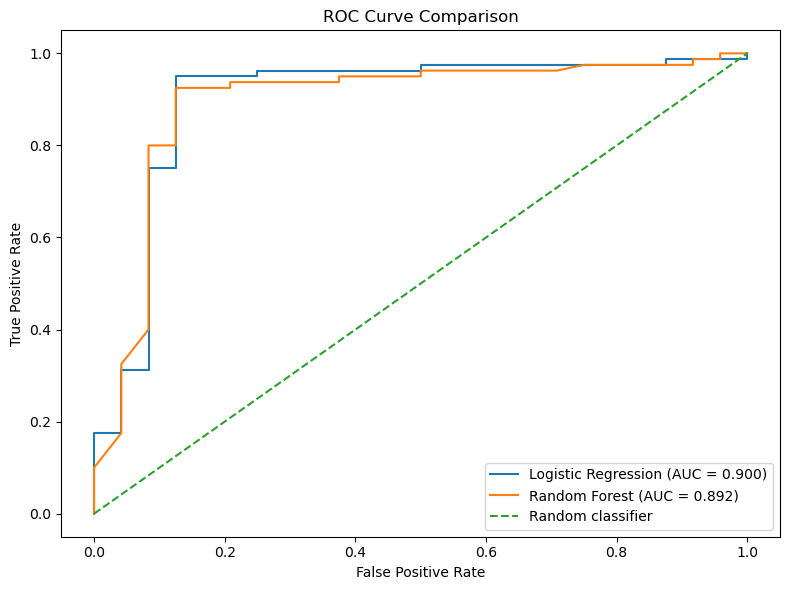

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()
plt.savefig("../results/figures/roc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_rf
    ],
    "F1-score": [
        f1,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_rf
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.923077,0.961538,0.9375,0.949367,0.900000
1,Random Forest,0.903846,0.937500,0.9375,0.937500,0.892448


## Model comparison

Two classification models were evaluated using the same training and test sets and the same selected gene features.

Logistic Regression achieved the best overall performance, with an accuracy of 92.3% and a ROC-AUC of 0.900, compared with 89.4% accuracy and a ROC-AUC of 0.885 for Random Forest.

These results suggest that the expression patterns selected in this analysis can effectively distinguish ER-positive from ER-negative samples. The slightly better performance of Logistic Regression also indicates that a relatively simple linear model is sufficient to capture much of the predictive signal in this dataset.

Because Logistic Regression provides both strong predictive performance and directly interpretable coefficients, it was selected as the preferred model for subsequent interpretation.

In [36]:
logistic_coefficients = pd.Series(
    logistic_model.coef_[0],
    index=selected_genes
)

top_positive_genes = (
    logistic_coefficients
    .sort_values(ascending=False)
    .head(20)
)

top_negative_genes = (
    logistic_coefficients
    .sort_values()
    .head(20)

)

print("Top genes associated with ER-positive predictions:")
print(top_positive_genes)

print("\nTop genes associated with ER-negative predictions:")
print(top_negative_genes)

Top genes associated with ER-positive predictions:
SBSN        0.222165
FBXL16      0.199845
AMDHD1      0.194612
NFE2L3      0.188107
KCTD6       0.183333
ZNF516      0.164696
LRRC56      0.161418
C6orf15     0.157869
LDHB        0.152276
PHGDH       0.152190
IMPA2       0.150648
SCCPDH      0.149735
ADCY5       0.149191
KIAA1257    0.148500
TFF1        0.147590
CBLN2       0.145781
SLC7A2      0.145764
CCKBR       0.141904
RTN4RL1     0.140603
CCDC78      0.139002
dtype: float64

Top genes associated with ER-negative predictions:
ZIC1      -0.250762
GALNT13   -0.225754
TMEM40    -0.214335
PAX6      -0.198935
MAP2      -0.198399
VLDLR     -0.192409
ASRGL1    -0.175694
ATAD4     -0.172113
KRT81     -0.160704
IGFALS    -0.158397
PGR       -0.155237
POP1      -0.154942
CHODL     -0.153564
UBXD3     -0.152891
AKR1CL2   -0.152884
NME5      -0.150462
NOL4      -0.150418
C1QL2     -0.150284
SOX11     -0.146746
VGLL1     -0.146331
dtype: float64


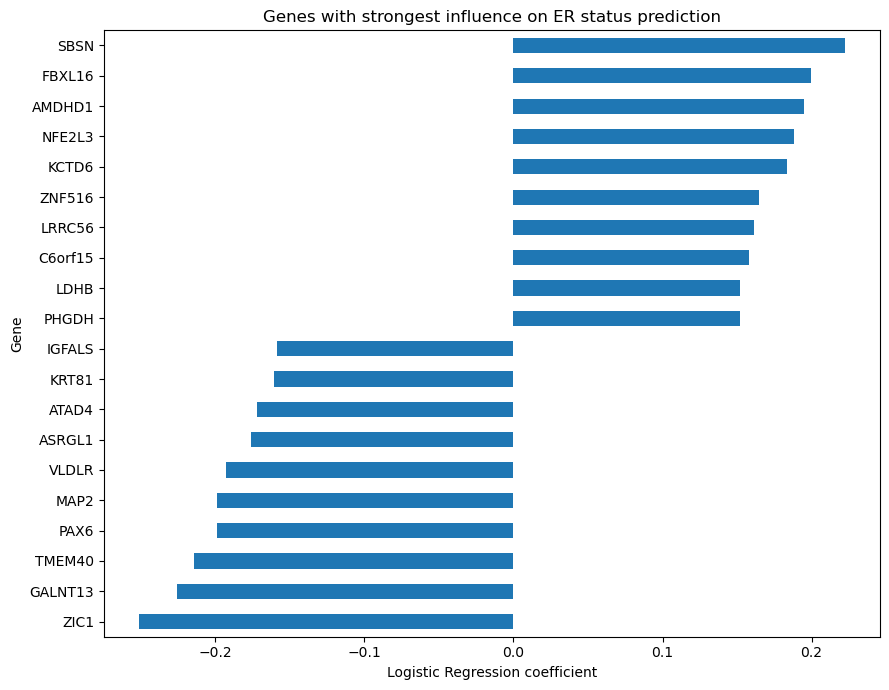

In [37]:
top_coefficients = pd.concat([
    logistic_coefficients.nlargest(10),
    logistic_coefficients.nsmallest(10)
]).sort_values()

plt.figure(figsize=(9, 7))

top_coefficients.plot(kind="barh")

plt.xlabel("Logistic Regression coefficient")
plt.ylabel("Gene")
plt.title("Genes with strongest influence on ER status prediction")

plt.tight_layout()
plt.savefig("../results/figures/logistic_regression_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
top_model_genes = set(
    top_positive_genes.index
).union(
    set(top_negative_genes.index)
)

differential_expression_genes = set(
    results_train["Gene"]
)

overlap_genes = sorted(
    top_model_genes.intersection(differential_expression_genes)
)

print("Top Logistic Regression genes:", len(top_model_genes))
print("Genes also present in differential expression results:", len(overlap_genes))
print("\nOverlapping genes:")
print(overlap_genes)

Top Logistic Regression genes: 40
Genes also present in differential expression results: 40

Overlapping genes:
['ADCY5', 'AKR1CL2', 'AMDHD1', 'ASRGL1', 'ATAD4', 'C1QL2', 'C6orf15', 'CBLN2', 'CCDC78', 'CCKBR', 'CHODL', 'FBXL16', 'GALNT13', 'IGFALS', 'IMPA2', 'KCTD6', 'KIAA1257', 'KRT81', 'LDHB', 'LRRC56', 'MAP2', 'NFE2L3', 'NME5', 'NOL4', 'PAX6', 'PGR', 'PHGDH', 'POP1', 'RTN4RL1', 'SBSN', 'SCCPDH', 'SLC7A2', 'SOX11', 'TFF1', 'TMEM40', 'UBXD3', 'VGLL1', 'VLDLR', 'ZIC1', 'ZNF516']


In [39]:
top_differential_genes = set(
    results_train
    .assign(abs_difference=results_train["mean_difference"].abs())
    .sort_values("abs_difference", ascending=False)
    .head(40)["Gene"]
)

model_gene_overlap = sorted(
    top_model_genes.intersection(top_differential_genes)
)

print("Overlap between top model genes and top differential genes:",
      len(model_gene_overlap))

print("\nOverlapping genes:")
print(model_gene_overlap)

Overlap between top model genes and top differential genes: 2

Overlapping genes:
['PGR', 'SOX11']


## Interpretation of model-derived gene importance

The genes identified by Logistic Regression provide a complementary perspective to the differential expression analysis performed previously.

The 40 genes with the strongest model coefficients were all among the genes previously selected for differential expression. This is expected, since feature selection was performed before model training using statistical significance and effect size.

More interestingly, when comparing the 40 genes with the strongest Logistic Regression coefficients with the 40 genes showing the largest expression differences between ER-positive and ER-negative samples, only two genes overlapped: **PGR** and **SOX11**.

This limited overlap is not contradictory. Differential expression and Logistic Regression address different questions. Differential expression identifies genes that show strong individual differences between the two groups, whereas Logistic Regression evaluates the contribution of genes jointly within a multivariate predictive model. Because gene expression features can be correlated, a gene with a large individual difference does not necessarily provide the greatest additional predictive value once other genes are considered.

Therefore, the results suggest that the predictive signal is not simply driven by the genes with the largest individual expression differences. Instead, Logistic Regression identifies a broader multigene pattern that can effectively distinguish ER-positive from ER-negative samples.

Overall, the combination of differential expression analysis and machine learning provides two complementary views of the data: statistical analysis identifies genes associated with ER status, while the predictive model identifies combinations of genes that are useful for classification.